P_star  = 0.303130
vx_star = 0.927453


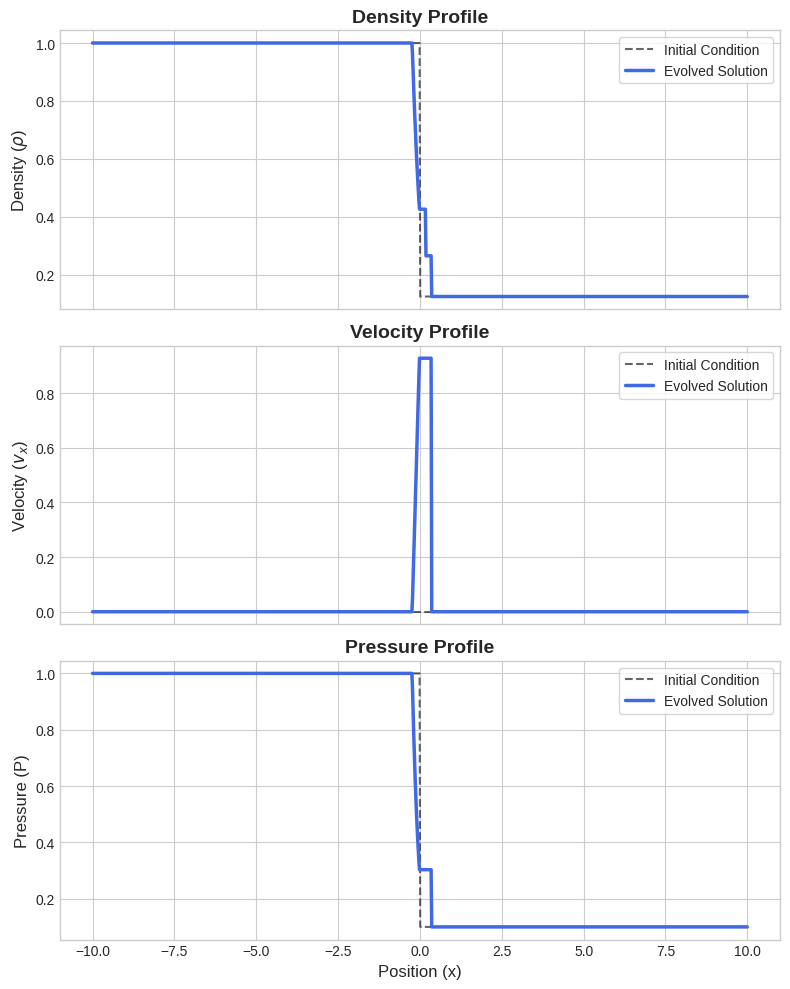

In [10]:
import matplotlib.pyplot as plt
import numpy as np

class RiemannSolver:
    def __init__(self, rho_L, vx_L, P_L, rho_R, vx_R, P_R, gamma, t):
        self.set_state(rho_L, vx_L, P_L, rho_R, vx_R, P_R, gamma, t)
        Lbox = 20.0
        N = 1024
        self.x = np.linspace(-Lbox / 2, Lbox / 2, N)
        self.rho = np.zeros(N)
        self.vx = np.zeros(N)
        self.P = np.zeros(N)

    def set_state(self, rho_L, vx_L, P_L, rho_R, vx_R, P_R, gamma, t):
        self.rho_L, self.vx_L, self.P_L = rho_L, vx_L, P_L
        self.rho_R, self.vx_R, self.P_R = rho_R, vx_R, P_R
        self.gamma, self.t = gamma, t
        self.g1 = (gamma - 1.0) / (2.0 * gamma)
        self.g2 = (gamma + 1.0) / (2.0 * gamma)
        self.g3 = 2.0 * gamma / (gamma - 1.0)
        self.g4 = 2.0 / (gamma - 1.0)
        self.g5 = 2.0 / (gamma + 1.0)
        self.g6 = (gamma - 1.0) / (gamma + 1.0)
        self.g7 = (gamma - 1.0) / 2.0
        self.g9 = 1.0 / gamma
        self.c_L = np.sqrt(gamma * P_L / rho_L)
        self.c_R = np.sqrt(gamma * P_R / rho_R)

    def calc_star_P_and_vx(self):
        tolerance = 1.0e-8
        max_iter = 100
        P_old = self.guess_P()
        vx_diff = self.vx_R - self.vx_L
        for _ in range(max_iter):
            f_L, df_L = self.pressure_function_and_derivative(P_old, self.rho_L, self.P_L, self.c_L)
            f_R, df_R = self.pressure_function_and_derivative(P_old, self.rho_R, self.P_R, self.c_R)
            P = P_old - (f_L + f_R + vx_diff) / (df_L + df_R)
            if abs((P - P_old) / (P + P_old)) < tolerance: break
            P_old = max(tolerance, P)
        vx = 0.5 * (self.vx_L + self.vx_R + f_R - f_L)
        return (P, vx)

    def guess_P(self):
        """
        Toro's pressure estimate.
        """

        q_threshold = 2.0

        cup = 0.25 * (self.rho_L + self.rho_R) * (self.c_L + self.c_R)

        P_pv = (
            0.5 * (self.P_L + self.P_R)
            + 0.5 * (self.vx_L - self.vx_R) * cup
        )

        P_pv = max(0.0, P_pv)

        P_min = min(self.P_L, self.P_R)
        P_max = max(self.P_L, self.P_R)

        q = P_max / P_min

        if (q < q_threshold) and (P_min < P_pv) and (P_pv < P_max):

            # Primitive Variable Riemann Solver
            P_guess = P_pv

        elif P_pv < P_min:

            # Two-Rarefaction Solver
            Pq = (self.P_L / self.P_R) ** self.g1

            vxm = (
                Pq * self.vx_L / self.c_L
                + self.vx_R / self.c_R
                + self.g4 * (Pq - 1.0)
            ) / (
                Pq / self.c_L + 1.0 / self.c_R
            )

            ptL = 1.0 + self.g7 * (self.vx_L - vxm) / self.c_L
            ptR = 1.0 + self.g7 * (vxm - self.vx_R) / self.c_R

            P_guess = 0.5 * (
                self.P_L * ptL ** self.g3
                + self.P_R * ptR ** self.g3
            )

        else:

            # Two-Shock Solver
            geL = np.sqrt(
                (self.g5 / self.rho_L)
                / (self.g6 * self.P_L + P_pv)
            )

            geR = np.sqrt(
                (self.g5 / self.rho_R)
                / (self.g6 * self.P_R + P_pv)
            )

            P_guess = (
                geL * self.P_L
                + geR * self.P_R
                - (self.vx_R - self.vx_L)
            ) / (
                geL + geR
            )

        return P_guess

    def pressure_function_and_derivative(self, P, rho_k, P_k, c_k):
        if P <= P_k:
            q = P / P_k
            f = self.g4 * c_k * (q**self.g1 - 1.0)
            df = (1.0 / (rho_k * c_k)) * q ** (-self.g2)
        else:
            ak = self.g5 / rho_k
            bk = self.g6 * P_k
            qrt = np.sqrt(ak / (bk + P))
            f = (P - P_k) * qrt
            df = (1.0 - 0.5 * (P - P_k) / (bk + P)) * qrt
        return (f, df)

    def sample(self, P_star, vx_star, s):
        if s <= vx_star:
            if P_star <= self.P_L:
                sh_L = self.vx_L - self.c_L
                if s <= sh_L: return self.rho_L, self.vx_L, self.P_L
                else:
                    cmL = self.c_L * (P_star / self.P_L) ** self.g1
                    st_L = vx_star - cmL
                    if s > st_L: return self.rho_L * (P_star / self.P_L) ** self.g9, vx_star, P_star
                    else:
                        vx = self.g5 * (self.c_L + self.g7 * self.vx_L + s)
                        c = self.g5 * (self.c_L + self.g7 * (self.vx_L - s))
                        return self.rho_L * (c / self.c_L) ** self.g4, vx, self.P_L * (c / self.c_L) ** self.g3
            else:
                P_starL = P_star / self.P_L
                s_L = self.vx_L - self.c_L * np.sqrt(self.g2 * P_starL + self.g1)
                if s <= s_L: return self.rho_L, self.vx_L, self.P_L
                else: return self.rho_L * (P_starL + self.g6) / (P_starL * self.g6 + 1.0), vx_star, P_star
        else:
            if P_star > self.P_R:
                P_starR = P_star / self.P_R
                s_R = self.vx_R + self.c_R * np.sqrt(self.g2 * P_starR + self.g1)
                if s >= s_R: return self.rho_R, self.vx_R, self.P_R
                else: return self.rho_R * (P_starR + self.g6) / (P_starR * self.g6 + 1.0), vx_star, P_star
            else:
                sh_R = self.vx_R + self.c_R
                if s >= sh_R: return self.rho_R, self.vx_R, self.P_R
                else:
                    cmR = self.c_R * (P_star / self.P_R) ** self.g1
                    st_R = vx_star + cmR
                    if s <= st_R: return self.rho_R * (P_star / self.P_R) ** self.g9, vx_star, P_star
                    else:
                        vx = self.g5 * (-self.c_R + self.g7 * self.vx_R + s)
                        c = self.g5 * (self.c_R - self.g7 * (self.vx_R - s))
                        return self.rho_R * (c / self.c_R) ** self.g4, vx, self.P_R * (c / self.c_R) ** self.g3

    def solve(self):

        P_star, vx_star = self.calc_star_P_and_vx()

        print(f"P_star  = {P_star:.6f}")
        print(f"vx_star = {vx_star:.6f}")

        for i, val in enumerate(self.x):
            rho, vx, P = self.sample(
                P_star,
                vx_star,
                val / self.t
            )

            self.rho[i] = rho
            self.vx[i] = vx
            self.P[i] = P

        return self.x, self.rho, self.vx, self.P

def plot_solution(x, rho, vx, P, rho_init, vx_init, P_init):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    
    # Define labels and titles for each plot
    plot_info = [
        (rho, rho_init, r'Density ($\rho$)', 'Density Profile'),
        (vx, vx_init, r'Velocity ($v_x$)', 'Velocity Profile'),
        (P, P_init, 'Pressure (P)', 'Pressure Profile')
    ]
    
    for ax, (val, init, ylabel, title) in zip(axes, plot_info):
        ax.plot(x, [init[0] if xi <= 0 else init[1] for xi in x], 
                'k--', alpha=0.6, label='Initial Condition')
        ax.plot(x, val, 'royalblue', linewidth=2.5, label='Evolved Solution')
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='upper right', frameon=True)

    axes[2].set_xlabel('Position (x)', fontsize=12)
    plt.tight_layout()
    plt.show()

# Execution
rs = RiemannSolver(
    rho_L=1.0,
    vx_L=0.0,
    P_L=1.0,
    rho_R=0.125,
    vx_R=0.0,
    P_R=0.1,
    gamma=1.4,
    t=0.2
)
x, rho, vx, P = rs.solve()
plot_solution(x, rho, vx, P, [1.0, 0.125], [0.0, 0.0], [1.0, 0.1])